**FASE 6 - Segunda Opção - "Ir Além" - Usando Transfer Learning e Fine Tuning**

Instalar o TensorFlow, biblioteca principal de Deep Learning

Instalar a versão mais recente do TensorFlow Addons diretamente do repositório GitHub

Força a instalação da versão 2.13.3 da biblioteca "typeguard"
(necessário porque algumas versões do TF Addons não são compatíveis com as mais novas)

In [ ]:
!pip install -q tensorflow tensorflow-hub matplotlib scikit-learn opencv-python
!pip install -q git+https://github.com/tensorflow/addons.git
!pip install -q typeguard==2.13.3


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


**Bibliotecas da própria linguagem Python**

os        → manipulação de diretórios e caminhos

time      → medir tempo de execução

json      → ler e salvar arquivos no formato JSON

shutil    → copiar, mover e apagar arquivos/pastas

glob      → buscar arquivos com padrões (*.jpg)

itertools → operações em iteradores (combinações, permutações)

math      → funções matemáticas (raiz, log)

random    → gerar números aleatórios

In [ ]:

import os, time, json, shutil, glob, itertools, math, random

# NumPy para operações matemáticas e matrizes (essencial para trabalhar com imagens)
import numpy as np

# TensorFlow para redes neurais
import tensorflow as tf

# TensorFlow Hub: acesso a modelos pré-treinados (DeepLab, MobileNet, etc.)
import tensorflow_hub as hub

# TensorFlow Addons: funções extras (otimizadores, métricas, camadas adicionais)
import tensorflow_addons as tfa

# Matplotlib: gerar gráficos e visualizar imagens
import matplotlib.pyplot as plt

# OpenCV: manipulação de imagens (ler, redimensionar, converter cores)
import cv2

# Scikit-learn: métricas de avaliação (relatório de classificação, matriz de confusão)
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow Keras: para criar modelos, camadas e redes neurais customizadas
from tensorflow.keras import layers, models

# Mostra a versão instalada do TensorFlow
print(tf.__version__)


/usr/local/lib/python3.12/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.19.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

2.19.0


**Importar módulo do Google Colab para acessar arquivos no Google Drive**

In [ ]:
from google.colab import drive
# Monta o Drive no caminho /content/drive
drive.mount('/content/drive')

# Define os diretórios principais
DRIVE_ROOT = '/content/drive/MyDrive/Fase6'
DATASET_ROOT = f'{DRIVE_ROOT}/dataset'          # onde ficam train/, val/, test/
RESULTS_DIR = f'{DRIVE_ROOT}/results_ir_alem2'  # pasta de saída dos resultados
os.makedirs(RESULTS_DIR, exist_ok=True)         # cria a pasta se não existir

# Hiperparâmetros do treinamento
IMG_SIZE = (224, 224)   # tamanho padrão das imagens que serão redimensionadas
BATCH_SIZE = 32         # número de imagens processadas por vez
SEED = 42               # número fixo para reprodutibilidade (aleatoriedade controlada)

# Detecta automaticamente as classes olhando dentro da pasta 'train'
CLASSES = sorted(next(os.walk(os.path.join(DATASET_ROOT, 'train')))[1])
print('Classes detectadas:', CLASSES)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes detectadas: ['escova', 'martelo']


In [ ]:
import os

# Mostrar o conteúdo da pasta de treino
print("Conteúdo de train:", os.listdir(os.path.join(DATASET_ROOT, 'train')))

# Mostrar o conteúdo da pasta de validação
print("Conteúdo de val:", os.listdir(os.path.join(DATASET_ROOT, 'val')))

# Mostrar o conteúdo da pasta de teste
print("Conteúdo de test:", os.listdir(os.path.join(DATASET_ROOT, 'test')))


Conteúdo de train: ['escova', 'martelo']
Conteúdo de val: ['escova', 'martelo']
Conteúdo de test: ['escova', 'martelo']


O **TensorFlow** é uma biblioteca open-source desenvolvida pelo **Google** para **Machine Learning** e **Deep Learning**.  
Ele permite criar, treinar e implantar redes neurais de forma simples e eficiente, aproveitando tanto **CPU** quanto **GPU**.

In [ ]:
import tensorflow as tf

# Carregar dataset de treino
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_ROOT, 'train'),  # caminho da pasta "train"
    image_size=IMG_SIZE,                  # redimensiona todas as imagens para (224,224)
    batch_size=BATCH_SIZE,                # número de imagens por lote (batch)
    seed=SEED                             # embaralhamento consistente
)

# Carregar dataset de validação
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_ROOT, 'val'),    # caminho da pasta "val"
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

# Carregar dataset de teste
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_ROOT, 'test'),   # caminho da pasta "test"
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)


Found 80 files belonging to 2 classes.
Found 10 files belonging to 2 classes.
Found 10 files belonging to 2 classes.


**Este bloco tem como objetivo:**

**Pré-processamento e Otimização do Dataset**

Normalização dos pixels.
As imagens originais têm pixels no intervalo **[0, 255]** (inteiros).  
Normalizar os valores entre **[0, 1]** (float) para melhorar a estabilidade do treinamento das redes neurais.


In [ ]:
# Normalizar os pixels (0 a 1)
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Aplica normalização a cada dataset
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Melhor performance em GPU
AUTOTUNE = tf.data.AUTOTUNE

# Otimização do pipeline de treino
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


**Inspeção do Dataset**

Este código serve para **visualizar a forma (shape) das imagens e rótulos (labels)** que o `train_ds` está fornecendo.

In [ ]:
for images, labels in train_ds.take(1):
    print("Batch de imagens:", images.shape)
    print("Batch de labels:", labels.numpy())

Batch de imagens: (32, 224, 224, 3)
Batch de labels: [1 1 0 0 0 1 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 1 0 0 1]


**Construção do Modelo com Transfer Learning (MobileNetV2)**

Neste trecho carregamos a rede **MobileNetV2**, já **pré-treinada na ImageNet** (milhões de imagens), e adaptamos para o nosso problema de classificar **escova x martelo**.

In [ ]:
# Carrega a base MobileNetV2 pré-treinada na ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),  # formato da entrada (224,224,3 → imagens coloridas RGB)
    include_top=False,            # remove as camadas finais originais (classificação da ImageNet)
    weights='imagenet'            # usa os pesos já treinados na base ImageNet
)

# Congelar a base para Transfer Learning
base_model.trainable = False

# Construir modelo final
model = tf.keras.Sequential([
    base_model,                                               # extrator de características
    tf.keras.layers.GlobalAveragePooling2D(),                 # reduz para um vetor (faz "resumo" das features)
    tf.keras.layers.Dense(128, activation='relu'),            # camada densa intermediária
    tf.keras.layers.Dropout(0.3),                             # regularização para evitar overfitting
    tf.keras.layers.Dense(len(CLASSES), activation='softmax') # saída final (2 classes: escova, martelo)
])

# Compilar o modelo
model.compile(
    optimizer='adam',                       # otimizador Adam (rápido e estável)
    loss='sparse_categorical_crossentropy', # função de perda para classificação com labels inteiros
    metrics=['accuracy']                    # avalia pelo acerto
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Treinamento do Modelo**

EPOCHS = 10  (pode ser testado com valores diferentes (30, 60))

In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,              # conjunto de treino
    validation_data=val_ds,# conjunto de validação (mede desempenho a cada epoch)
    epochs=EPOCHS          # número de épocas
)

# Avaliação final no conjunto de teste
loss, acc = model.evaluate(test_ds)
print("Acurácia no conjunto de teste:", acc)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 43s 13s/step - accuracy: 0.5648 - loss: 0.7424 - val_accuracy: 1.0000 - val_loss: 0.0583
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9552 - loss: 0.1152 - val_accuracy: 1.0000 - val_loss: 0.0125
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9552 - loss: 0.1286 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9898 - loss: 0.0321 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 6.7635e-04
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 4.0260e-04
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0097 - val_accuracy: 1.0000 - val_loss: 2.7548e-04
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 1.0000 - val_l

**Visualização do Treinamento**

Depois do treinamento, podemos analisar o desempenho do modelo através de gráficos de **acurácia** e **loss (erro)**.

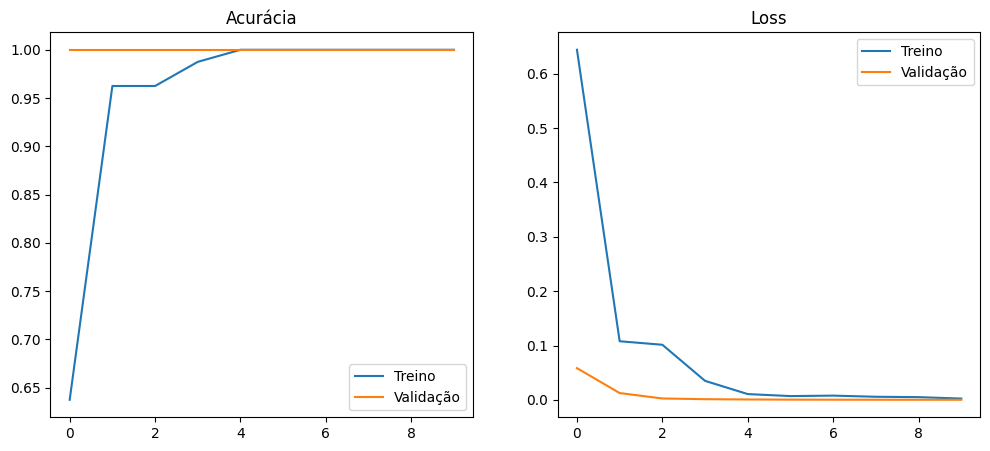

In [ ]:
import matplotlib.pyplot as plt

# Extrai os valores armazenados no objeto "history"
acc = history.history['accuracy']         # acurácia no treino
val_acc = history.history['val_accuracy'] # acurácia na validação
loss = history.history['loss']            # perda (erro) no treino
val_loss = history.history['val_loss']    # perda na validação

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)   # Gráfico 1 (esquerda)
plt.plot(acc, label='Treino')
plt.plot(val_acc, label='Validação')
plt.title('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)   # Gráfico 2 (direita)
plt.plot(loss, label='Treino')
plt.plot(val_loss, label='Validação')
plt.title('Loss')
plt.legend()

plt.show()

**Fine-Tuning (Ajuste Fino da Rede)**

Depois do treinamento inicial usando **Transfer Learning** com a base MobileNetV2 congelada, liberamos algumas camadas para que o modelo se adaptesse melhor ao nosso dataset específico.

In [ ]:
# Descongelar parte da base
base_model.trainable = True

# Congelar apenas as primeiras camadas para não perder os pesos pré-treinados
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompilar com learning rate menor
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Re-treinar com Fine Tuning
fine_tune_epochs = 10
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)

# Avaliar novamente no conjunto de teste
loss, acc = model.evaluate(test_ds)
print("Acurácia após Fine Tuning:", acc)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 8s/step - accuracy: 1.0000 - loss: 0.0492 - val_accuracy: 1.0000 - val_loss: 1.2064e-04
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9820 - loss: 0.0628 - val_accuracy: 1.0000 - val_loss: 1.0972e-04
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9937 - loss: 0.0352 - val_accuracy: 1.0000 - val_loss: 1.0133e-04
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 0.0229 - val_accuracy: 1.0000 - val_loss: 9.3588e-05
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0222 - val_accuracy: 1.0000 - val_loss: 8.6378e-05
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9898 - loss: 0.0289 - val_accuracy: 1.0000 - val_loss: 8.0384e-05
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 7.5915e-05
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy:

In [ ]:
import os

# Caminho da pasta do modelo no Google Drive
MODEL_DIR = '/content/drive/MyDrive/Fase6/modelos/deeplabv3_pascal_train_aug'

# Verificar o conteúdo da pasta
print("Arquivos do modelo:", os.listdir(MODEL_DIR))

# Dentro dessa pasta existe um subdiretório 'frozen_inference_graph.pb' ou similar.
MODEL_PATH = os.path.join(MODEL_DIR, 'frozen_inference_graph.pb')
print("Caminho do modelo carregado:", MODEL_PATH)

Arquivos do modelo: ['frozen_inference_graph.pb', 'model.ckpt.data-00000-of-00001', 'model.ckpt.index']
Caminho do modelo carregado: /content/drive/MyDrive/Fase6/modelos/deeplabv3_pascal_train_aug/frozen_inference_graph.pb


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/Fase6/dataset/test/escova'))

['escova_teste (4).jpg', 'escova_teste (1).jpg', 'escova_teste (2).jpg', 'escova_teste (5).jpg', 'escova_teste (3).jpg']


**Segmentação de Imagens com DeepLabV3**

Aqui utilizamos o modelo **DeepLabV3 pré-treinado** (em Pascal VOC) para **segmentar objetos em imagens** do nosso dataset (escova e martelo).

In [ ]:
import tensorflow as tf
import cv2
import numpy as np

# Caminho do modelo congelado
MODEL_PATH = '/content/drive/MyDrive/Fase6/modelos/deeplabv3_pascal_train_aug/frozen_inference_graph.pb'

# Criar uma função para carregar o modelo do arquivo .pb
def load_frozen_graph(model_path):
    graph = tf.Graph()
    with tf.io.gfile.GFile(model_path, "rb") as f:
        graph_def = tf.compat.v1.GraphDef()
        graph_def.ParseFromString(f.read())
    with graph.as_default():
        tf.import_graph_def(graph_def, name="")
    return graph

# Carregar o grafo congelado
graph = load_frozen_graph(MODEL_PATH)
print("Modelo carregado com sucesso!")

# Criar uma sessão para rodar a segmentação
sess = tf.compat.v1.Session(graph=graph)

# Função para rodar segmentação
def segment_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Não foi possível carregar a imagem: {image_path}")

    h, w = image.shape[:2]

    # Redimensionar para 513x513 (ou outro múltiplo válido)
    image_resized = cv2.resize(image, (513, 513))
    batch = np.expand_dims(image_resized, axis=0)

    input_tensor = graph.get_tensor_by_name('ImageTensor:0')
    output_tensor = graph.get_tensor_by_name('SemanticPredictions:0')

    segmentation = sess.run(output_tensor, feed_dict={input_tensor: batch})
    mask = segmentation[0]

    # Redimensionar a máscara de volta para o tamanho original da imagem
    mask_resized = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)

    return image, mask_resized

# Exemplo de uso
image_path = '/content/drive/MyDrive/Fase6/dataset/test/escova/escova_teste (1).jpg'  # troque por uma imagem real do seu dataset
original, mask = segment_image(image_path)

print("Segmentação concluída! Máscara gerada com tamanho:", mask.shape)

Modelo carregado com sucesso!
Segmentação concluída! Máscara gerada com tamanho: (410, 612)


**Salvando Máscaras Segmentadas**

Depois de gerar a máscara com o **DeepLabV3**, precisamos salvar os resultados em disco para documentação e uso posterior.

In [ ]:
output_folder = '/content/drive/MyDrive/Fase6/results_segmentados/escova'
os.makedirs(output_folder, exist_ok=True)

# Nome do arquivo de saída
filename = os.path.basename(image_path)
save_path = os.path.join(output_folder, f"mask_{filename}")

# Salvar a máscara como imagem
cv2.imwrite(save_path, mask*255)
print("Máscara salva em:", save_path)

Máscara salva em: /content/drive/MyDrive/Fase6/results_segmentados/escova/mask_escova_teste (1).jpg


**Criando Overlays Coloridos**

Além da máscara binária, podemos gerar **overlays coloridos** que destacam a região segmentada dentro da imagem original.  
Isso facilita a análise e torna os resultados mais claros para relatórios e apresentações.

In [ ]:
# Criar uma versão colorida da máscara
mask_color = cv2.applyColorMap(mask*20, cv2.COLORMAP_JET)

# Misturar imagem original e máscara (50% cada)
overlay = cv2.addWeighted(original, 0.7, mask_color, 0.3, 0)

# Salvar resultado final
overlay_path = os.path.join(output_folder, f"overlay_{filename}")
cv2.imwrite(overlay_path, overlay)
print("Overlay salvo em:", overlay_path)

Overlay salvo em: /content/drive/MyDrive/Fase6/results_segmentados/escova/overlay_escova_teste (1).jpg


In [ ]:
import glob

input_folder = '/content/drive/MyDrive/Fase6/dataset/test/escova'
output_folder = '/content/drive/MyDrive/Fase6/results_segmentados/escova'
os.makedirs(output_folder, exist_ok=True)

for img_path in glob.glob(os.path.join(input_folder, '*.jpg')):
    original, mask = segment_image(img_path)
    filename = os.path.basename(img_path)

    # Salvar máscara
    save_path = os.path.join(output_folder, f"mask_{filename}")
    cv2.imwrite(save_path, mask*255)

    # Salvar overlay
    mask_color = cv2.applyColorMap(mask*20, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(original, 0.7, mask_color, 0.3, 0)
    overlay_path = os.path.join(output_folder, f"overlay_{filename}")
    cv2.imwrite(overlay_path, overlay)

    print(f"Processado e salvo: {filename}")

Processado e salvo: escova_teste (4).jpg
Processado e salvo: escova_teste (1).jpg
Processado e salvo: escova_teste (2).jpg
Processado e salvo: escova_teste (5).jpg
Processado e salvo: escova_teste (3).jpg


In [ ]:
import glob

input_folder = '/content/drive/MyDrive/Fase6/dataset/test/martelo'
output_folder = '/content/drive/MyDrive/Fase6/results_segmentados/martelo'
os.makedirs(output_folder, exist_ok=True)

for img_path in glob.glob(os.path.join(input_folder, '*.jpg')):
    original, mask = segment_image(img_path)
    filename = os.path.basename(img_path)

    # Salvar máscara
    save_path = os.path.join(output_folder, f"mask_{filename}")
    cv2.imwrite(save_path, mask*255)

    # Salvar overlay
    mask_color = cv2.applyColorMap(mask*20, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(original, 0.7, mask_color, 0.3, 0)
    overlay_path = os.path.join(output_folder, f"overlay_{filename}")
    cv2.imwrite(overlay_path, overlay)

    print(f"Processado e salvo: {filename}")

Processado e salvo: teste_martelo (3).jpg
Processado e salvo: teste_martelo (2).jpg
Processado e salvo: teste_martelo (4).jpg
Processado e salvo: teste_martelo (1).jpg
Processado e salvo: teste_martelo (5).jpg


**Segmentação em Lote (Batch Segmentation)**

Este bloco de código aplica a função `segment_image` para **todas as imagens do dataset** (`train`, `val` e `test`) e salva os resultados em uma estrutura organizada no Google Drive.

**Estrutura de saída**

Os resultados são salvos.

- `mask/` → contém as máscaras binárias (0 = fundo, 1 = objeto).  
- `overlay/` → contém imagens originais sobrepostas com a segmentação em cores.  


✅ Finalizado: escova
✅ Finalizado: martelo


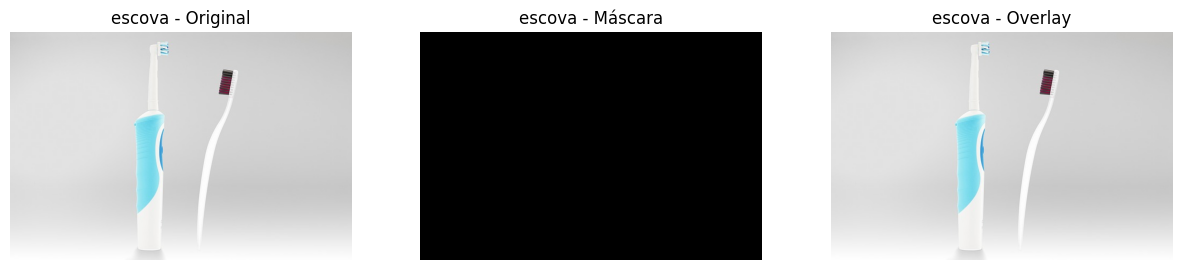

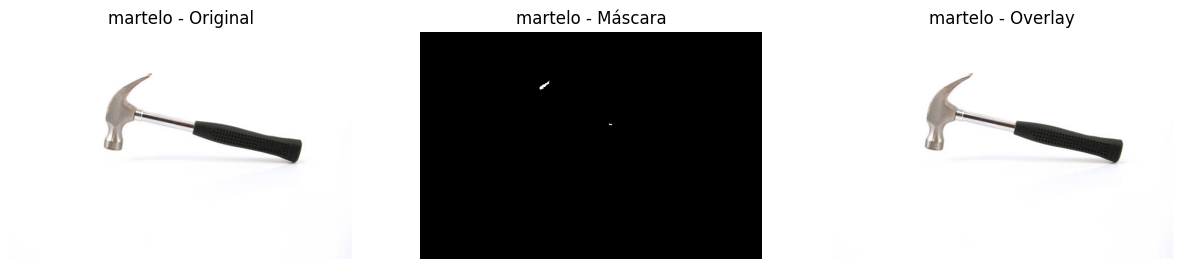

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Diretório base do dataset
TEST_DIR = '/content/drive/MyDrive/Fase6/dataset/test'
RESULTS_DIR = '/content/drive/MyDrive/Fase6/results_segmentados'

# Cria as pastas de resultados
for class_name in os.listdir(TEST_DIR):
    os.makedirs(os.path.join(RESULTS_DIR, class_name, "original"), exist_ok=True)
    os.makedirs(os.path.join(RESULTS_DIR, class_name, "mask"), exist_ok=True)
    os.makedirs(os.path.join(RESULTS_DIR, class_name, "overlay"), exist_ok=True)

def salvar_resultados(image_path, class_name, filename):
    # Segmentar imagem
    original, mask = segment_image(image_path)

    # Criar overlay
    overlay = original.copy()
    overlay[mask == 1] = [0, 255, 0]  # verde para pixels do objeto

    # Caminhos de saída
    class_dir = os.path.join(RESULTS_DIR, class_name)
    mask_path = os.path.join(class_dir, "mask", f"mask_{filename}")
    overlay_path = os.path.join(class_dir, "overlay", f"overlay_{filename}")
    original_path = os.path.join(class_dir, "original", f"original_{filename}")

    # Salvar arquivos
    cv2.imwrite(mask_path, mask)
    cv2.imwrite(overlay_path, overlay)
    cv2.imwrite(original_path, original)

    return original, mask, overlay

# Loop para processar todas as imagens do test/
for class_name in os.listdir(TEST_DIR):
    class_path = os.path.join(TEST_DIR, class_name)
    for filename in os.listdir(class_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(class_path, filename)
            salvar_resultados(img_path, class_name, filename)
    print(f"✅ Finalizado: {class_name}")

# Mostrar exemplos visuais (primeiras imagens de cada classe)
for class_name in os.listdir(TEST_DIR):
    example_file = os.listdir(os.path.join(TEST_DIR, class_name))[0]
    img_path = os.path.join(TEST_DIR, class_name, example_file)
    original, mask, overlay = salvar_resultados(img_path, class_name, example_file)

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(f"{class_name} - Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"{class_name} - Máscara")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"{class_name} - Overlay")
    plt.axis("off")

    plt.show()


Found 80 images belonging to 2 classes.
Found 10 images belonging to 2 classes.

Treinando apenas a última camada (Transfer Learning básico)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.3479 - loss: 0.9199 - val_accuracy: 0.8000 - val_loss: 0.5452
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - accuracy: 0.6875 - loss: 0.5771 - val_accuracy: 1.0000 - val_loss: 0.3254
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.9094 - loss: 0.3798 - val_accuracy: 1.0000 - val_loss: 0.2001
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.9042 - loss: 0.2680 - val_accuracy: 1.0000 - val_loss: 0.1306
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.9656 - loss: 0.1958 - val_accuracy: 1.0000 - val_loss: 0.0945

Agora treinando com Fine-Tuning (últimas 20 camadas descongeladas)...
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.9031 - loss: 0.3196 - val_accuracy: 1.0000 - val_loss: 0.0897
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step - accuracy: 0.8927 - loss: 0.3101 - val_accuracy: 1.0000 - val_loss: 0.0841
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accurac

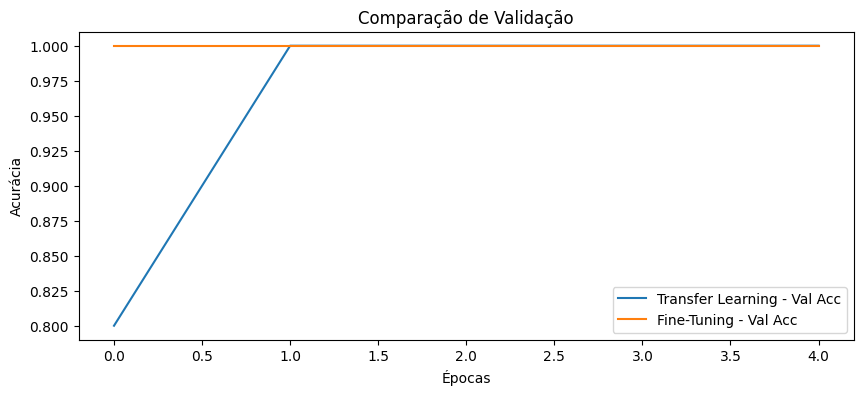

In [ ]:
# ================================================================
# EXEMPLO DE FINE-TUNING (ESCOVA x MARTELO)
# ================================================================
# Este código mostra a diferença entre:
# 1. Transfer Learning básico (todas as camadas congeladas, só treina a última camada)
# 2. Fine-Tuning (descongela algumas camadas intermediárias e treina novamente)
# ================================================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --------------------------
# 1. Diretórios do dataset
# --------------------------
# Espera-se que as imagens estejam organizadas assim:
# dataset/
#   train/
#       escova/
#       martelo/
#   val/
#       escova/
#       martelo/
DATASET_ROOT = '/content/drive/MyDrive/Fase6/dataset'
train_dir = f"{DATASET_ROOT}/train"
val_dir   = f"{DATASET_ROOT}/val"

# --------------------------
# 2. Pré-processamento
# --------------------------
# Normalizamos as imagens (0-1) e redimensionamos para 224x224 pixels
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32, class_mode='categorical'
)

val_gen = datagen.flow_from_directory(
    val_dir, target_size=(224,224), batch_size=32, class_mode='categorical'
)

# --------------------------
# 3. Transfer Learning (BÁSICO)
# --------------------------
# Usamos o MobileNetV2 pré-treinado no ImageNet (1.4M de imagens, 1000 classes).
# include_top=False -> removemos a camada final original (com 1000 classes).
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Congelamos TODAS as camadas do modelo base
base_model.trainable = False

# Criamos a "cabeça" personalizada do nosso modelo (para 2 classes: escova, martelo)
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(2, activation='softmax')  # saída para 2 classes
])

# Compilamos o modelo - apenas a última camada será treinada
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nTreinando apenas a última camada (Transfer Learning básico)...")
history_tl = model.fit(train_gen, validation_data=val_gen, epochs=5)

# --------------------------
# 4. Fine-Tuning (ajuste fino)
# --------------------------
# Agora, vamos descongelar as últimas 20 camadas do modelo base
# Isso permite que a rede ajuste também essas camadas para o nosso dataset específico.
for layer in base_model.layers[-20:]:
    layer.trainable = True

# MUITO IMPORTANTE: recompilar o modelo após mudar trainable
# Usamos uma taxa de aprendizado menor para não "estragar" os pesos já aprendidos
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\nAgora treinando com Fine-Tuning (últimas 20 camadas descongeladas)...")
history_ft = model.fit(train_gen, validation_data=val_gen, epochs=5)

# --------------------------
# 5. Comparação dos resultados
# --------------------------
# Vamos comparar a acurácia de validação (val_accuracy)
# entre o Transfer Learning simples e o Fine-Tuning
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(history_tl.history['val_accuracy'], label='Transfer Learning - Val Acc')
plt.plot(history_ft.history['val_accuracy'], label='Fine-Tuning - Val Acc')
plt.title("Comparação de Validação")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.show()


**Esse bloco de código serve para comparar visualmente o desempenho do modelo em duas fases:**

Treinamento inicial com Transfer Learning (camadas da MobileNetV2 congeladas).

Fine-Tuning (parte das camadas descongeladas e ajustadas ao dataset).

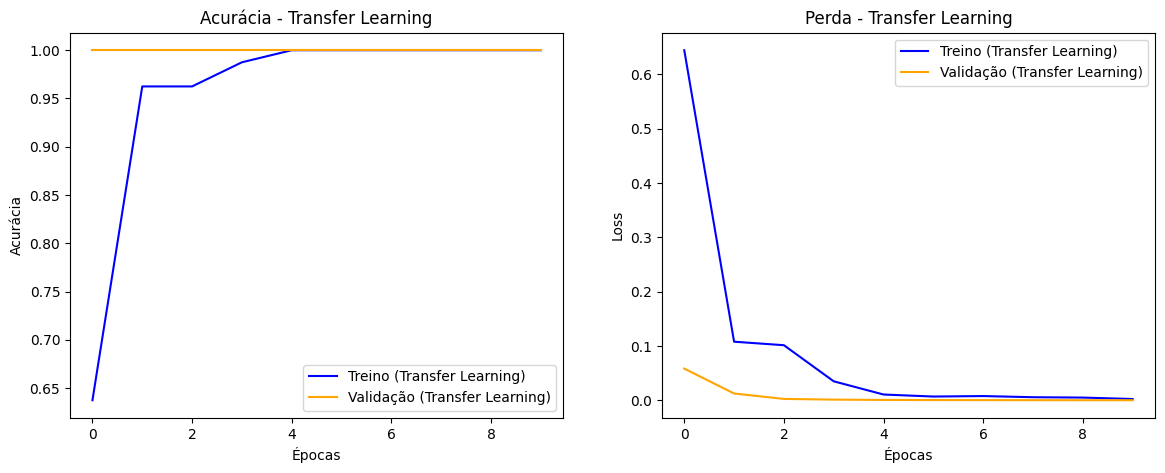

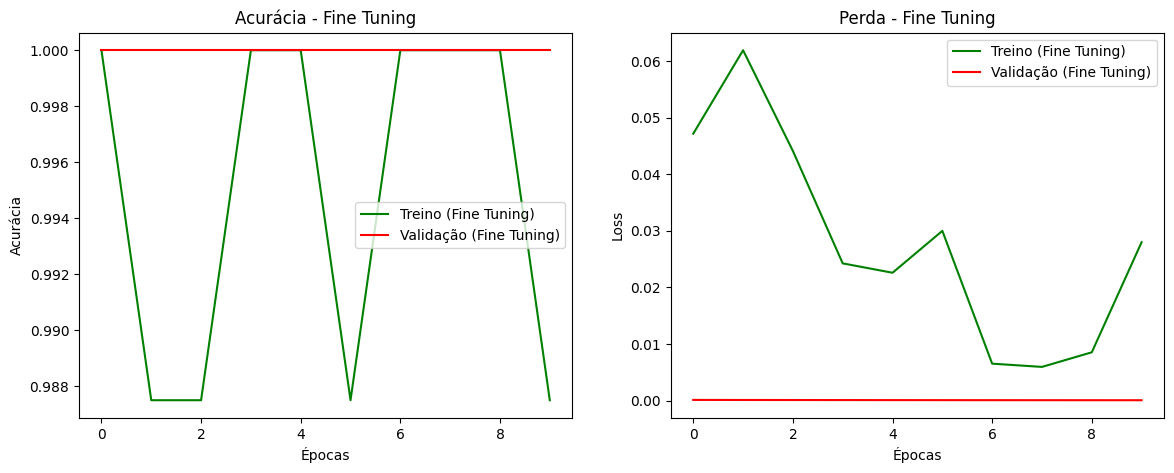

In [ ]:
import matplotlib.pyplot as plt

# Acurácia e perda durante o treinamento inicial (Transfer Learning)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Acurácia e perda durante o Fine-Tuning
fine_acc = history_fine.history['accuracy']
fine_val_acc = history_fine.history['val_accuracy']
fine_loss = history_fine.history['loss']
fine_val_loss = history_fine.history['val_loss']

# Gráfico 1: Transfer Learning
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Treino (Transfer Learning)', color='blue')
plt.plot(val_acc, label='Validação (Transfer Learning)', color='orange')
plt.title('Acurácia - Transfer Learning')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Treino (Transfer Learning)', color='blue')
plt.plot(val_loss, label='Validação (Transfer Learning)', color='orange')
plt.title('Perda - Transfer Learning')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Gráfico 2: Fine-Tuning
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(fine_acc, label='Treino (Fine Tuning)', color='green')
plt.plot(fine_val_acc, label='Validação (Fine Tuning)', color='red')
plt.title('Acurácia - Fine Tuning')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fine_loss, label='Treino (Fine Tuning)', color='green')
plt.plot(fine_val_loss, label='Validação (Fine Tuning)', color='red')
plt.title('Perda - Fine Tuning')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()
